<a href="https://colab.research.google.com/github/raj-aryan7/ProteinBERT/blob/main/notebooks/LSTM_with_pretraining_new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tape-proteins
!pip install lmdb
!pip install biopython
!pip install torch torchvision
!pip install pandas numpy scikit-learn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.9/68.9 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.2/301.2 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 72.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 10.6 MB/s eta 0:00:00


In [2]:
!wget https://s3.amazonaws.com/songlabdata/proteindata/data_pytorch/secondary_structure.tar.gz
!tar -xzf secondary_structure.tar.gz

!mkdir -p data
!mv secondary_structure data/

--2026-03-16 18:01:46--  https://s3.amazonaws.com/songlabdata/proteindata/data_pytorch/secondary_structure.tar.gz
Resolving s3.amazonaws.com (s3.amazonaws.com)... 16.15.236.114, 16.15.205.176, 52.217.194.104, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|16.15.236.114|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 251794897 (240M) [application/x-tar]
Saving to: ‘secondary_structure.tar.gz’

secondary_structure 100%[===================>] 240.13M  29.8MB/s    in 8.0s    

2026-03-16 18:01:55 (30.1 MB/s) - ‘secondary_structure.tar.gz’ saved [251794897/251794897]



In [15]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence

from tape.datasets import SecondaryStructureDataset
from tape import TAPETokenizer

from tqdm import tqdm

In [13]:
train_dataset = SecondaryStructureDataset(
    data_path='./data',
    split='train'
)

valid_dataset = SecondaryStructureDataset(
    data_path='./data',
    split='valid'
)

print("Train size:", len(train_dataset))
print("Valid size:", len(valid_dataset))

Train size: 8678
Valid size: 2170


In [14]:
tokenizer = TAPETokenizer(vocab='iupac')

In [16]:
def collate_fn(batch):

    sequences = []
    labels = []

    for item in batch:
        seq, mask, target = item
        sequences.append(torch.tensor(seq))
        labels.append(torch.tensor(target))

    sequences = pad_sequence(sequences, batch_first=True)
    labels = pad_sequence(labels, batch_first=True, padding_value=-1)

    return sequences, labels

In [17]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=collate_fn
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=collate_fn
)

In [18]:
class ProteinLSTMPretrain(nn.Module):

    def __init__(self, vocab_size=30, embed_dim=128, hidden_dim=256):

        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(hidden_dim*2, vocab_size)

    def forward(self, x):

        x = self.embedding(x)

        x,_ = self.lstm(x)

        x = self.fc(x)

        return x

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

pretrain_model = ProteinLSTMPretrain().to(device)

criterion = nn.CrossEntropyLoss(ignore_index=-1)

optimizer = optim.Adam(pretrain_model.parameters(), lr=1e-3)

cuda


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

pretrain_model = ProteinLSTMPretrain().to(device)

criterion = nn.CrossEntropyLoss(ignore_index=-1)

optimizer = optim.Adam(pretrain_model.parameters(), lr=1e-3)

In [20]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

In [21]:
epochs = 20

for epoch in range(epochs):

    pretrain_model.train()

    total_loss = 0

    for inputs, labels in tqdm(train_loader):

        inputs = inputs.to(device)

        optimizer.zero_grad()

        outputs = pretrain_model(inputs)

        loss = criterion(
            outputs.view(-1,30),
            inputs.view(-1)
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print("Pretrain Epoch", epoch+1, "Loss:", total_loss/len(train_loader))

100%|██████████| 543/543 [00:23<00:00, 23.21it/s]


Pretrain Epoch 1 Loss: 0.0704549450715813


100%|██████████| 543/543 [00:21<00:00, 24.86it/s]


Pretrain Epoch 2 Loss: 0.0001429984256777716


100%|██████████| 543/543 [00:22<00:00, 23.91it/s]


...

Pretrain Epoch 18 Loss: 2.369227260444266e-07


100%|██████████| 543/543 [00:22<00:00, 24.05it/s]


Pretrain Epoch 19 Loss: 1.796395019576176e-07


100%|██████████| 543/543 [00:22<00:00, 23.68it/s]

Pretrain Epoch 20 Loss: 1.3204976212958877e-07


In [22]:
torch.save(pretrain_model.state_dict(), "pretrained_lstm.pt")

In [23]:
class LSTMSecondaryStructure(nn.Module):

    def __init__(self, vocab_size=30, embed_dim=128, hidden_dim=256, num_classes=3):

        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(hidden_dim*2, num_classes)

    def forward(self, x):

        x = self.embedding(x)

        x,_ = self.lstm(x)

        x = self.fc(x)

        return x

In [26]:
model = LSTMSecondaryStructure().to(device)

pretrained_dict = torch.load("pretrained_lstm.pt")

model.embedding.weight.data = pretrained_dict["embedding.weight"]

model.lstm.weight_ih_l0.data = pretrained_dict["lstm.weight_ih_l0"]
model.lstm.weight_hh_l0.data = pretrained_dict["lstm.weight_hh_l0"]

In [27]:
criterion = nn.CrossEntropyLoss(ignore_index=-1)

optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [28]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

In [29]:
epochs = 20

for epoch in range(epochs):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for inputs, labels in tqdm(train_loader):

        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(
            outputs.view(-1,3),
            labels.view(-1)
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=-1)

        mask = labels != -1

        correct += (preds[mask] == labels[mask]).sum().item()
        total += mask.sum().item()

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    print("\nEpoch", epoch+1)
    print("Train Loss:", train_loss)
    print("Train Acc:", train_acc)


    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for inputs, labels in valid_loader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            loss = criterion(
                outputs.view(-1,3),
                labels.view(-1)
            )

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=-1)

            mask = labels != -1

            correct += (preds[mask] == labels[mask]).sum().item()
            total += mask.sum().item()

    val_loss = val_loss / len(valid_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print("Val Loss:", val_loss)
    print("Val Acc:", val_acc)

  0%|          | 0/543 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1141: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1480.)
  result = _VF.lstm(
100%|██████████| 543/543 [00:24<00:00, 22.30it/s]



Epoch 1
Train Loss: 0.8468574070359681
Train Acc: 0.6138598707994168
Val Loss: 0.7906848218511132
Val Acc: 0.649326397704563


100%|██████████| 543/543 [00:23<00:00, 23.30it/s]



Epoch 2
Train Loss: 0.7828566620802133
Train Acc: 0.6530287773119778
Val Loss: 0.7686190762940575
Val Acc: 0.6603780360583268


100%|██████████| 543/543 [00:23<00:00, 23.43it/s]


...


Epoch 18
Train Loss: 0.6539221431229875
Train Acc: 0.7186531485158498
Val Loss: 0.6727719460340107
Val Acc: 0.7094146312559365


100%|██████████| 543/543 [00:23<00:00, 23.30it/s]



Epoch 19
Train Loss: 0.6509218012869468
Train Acc: 0.7200472472065134
Val Loss: 0.6757034444633652
Val Acc: 0.7082582941154291


100%|██████████| 543/543 [00:23<00:00, 23.33it/s]



Epoch 20
Train Loss: 0.6484868736117804
Train Acc: 0.721256786496734
Val Loss: 0.674377532566295
Val Acc: 0.7090160181422833


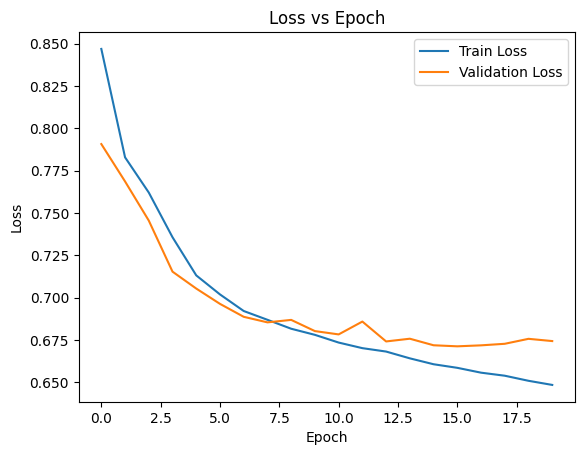

In [30]:
plt.figure()

plt.plot(train_losses,label="Train Loss")
plt.plot(val_losses,label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Loss vs Epoch")

plt.legend()

plt.show()

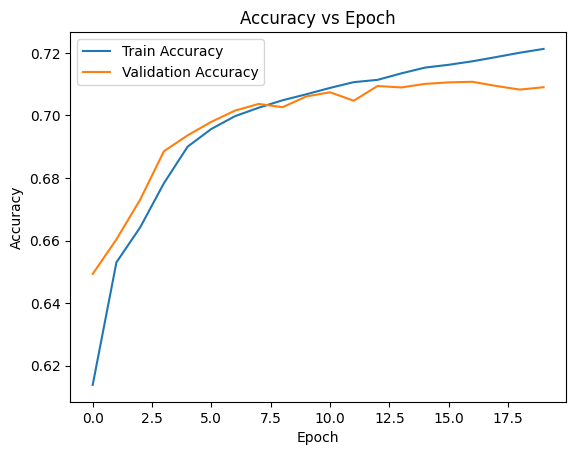

In [31]:
plt.figure()

plt.plot(train_accuracies,label="Train Accuracy")
plt.plot(val_accuracies,label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Accuracy vs Epoch")

plt.legend()

plt.show()

In [32]:
test_dataset = SecondaryStructureDataset(
    data_path='./data',
    split='cb513'
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=collate_fn
)

In [33]:
model.eval()

correct = 0
total = 0
test_loss = 0

with torch.no_grad():

    for inputs, labels in test_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)

        loss = criterion(
            outputs.view(-1,3),
            labels.view(-1)
        )

        test_loss += loss.item()

        preds = torch.argmax(outputs, dim=-1)

        mask = labels != -1

        correct += (preds[mask] == labels[mask]).sum().item()
        total += mask.sum().item()

test_accuracy = correct/total
test_loss = test_loss/len(test_loader)

print("Test Loss:",test_loss)
print("Test Accuracy:",test_accuracy)

Test Loss: 0.7077999151114261
Test Accuracy: 0.6960030479357162


In [34]:
print("\nExperiment Completed")

print("Model: LSTM with Pretraining")

print("Train samples:",len(train_dataset))
print("Validation samples:",len(valid_dataset))

print("Epochs:",epochs)

print("Final Train Accuracy:",train_accuracies[-1])
print("Final Validation Accuracy:",val_accuracies[-1])
print("Test Accuracy:",test_accuracy)


Experiment Completed
Model: LSTM with Pretraining
Train samples: 8678
Validation samples: 2170
Epochs: 20
Final Train Accuracy: 0.721256786496734
Final Validation Accuracy: 0.7090160181422833
Test Accuracy: 0.6960030479357162
